In [13]:
import xarray as xr
import numpy as np
import folium
from folium.plugins import HeatMap
import glob

print("Loading TROPOMI methane...")
files = glob.glob('/home/vittoria/methane-justice/data/tropomi/200301_202312-C3S-L3_XCH4-GHG_PRODUCTS-MERGED-MERGED-OBS4MIPS-MERGED-v4.6.nc')
ds = xr.open_dataset(files[0])

# Get latest month
latest_xch4 = ds['xch4'].isel(time=-1).astype('float64')  # Convert to float64
print(f"Latest data: {ds.time.values[-1]}")

lats = ds.lat.values
lons = ds.lon.values
ch4_values = latest_xch4.values

# Get valid range
valid_ch4 = ch4_values[~np.isnan(ch4_values)]
ch4_min = float(valid_ch4.min())
ch4_max = float(valid_ch4.max())
print(f"Methane range: {ch4_min:.1f} - {ch4_max:.1f} ppb")

# Create heatmap data
heat_data = []
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        val = float(ch4_values[i, j])  # Convert to Python float
        if not np.isnan(val):
            normalized = (val - ch4_min) / (ch4_max - ch4_min)
            heat_data.append([float(lat), float(lon), normalized])

print(f"Heatmap points: {len(heat_data)}")

# Create map
m = folium.Map(location=[20, 0], zoom_start=2, tiles='OpenStreetMap')
HeatMap(heat_data, radius=40, blur=20, max_zoom=2, min_opacity=0.3, 
        gradient={0.0: 'green', 0.5: 'yellow', 1.0: 'red'}).add_to(m)

title_html = '''<div style="position: fixed; top: 10px; left: 50px; width: 400px; 
background-color: white; border:2px solid grey; z-index:9999; font-size:14px; padding:10px; border-radius:5px;">
<b>REAL TROPOMI Methane</b><br>Global satellite observations</div>'''
m.get_root().html.add_child(folium.Element(title_html))

m.save('../outputs/05-tropomi-global-methane.html')
print("✓ Map saved!")

Loading TROPOMI methane...
Latest data: 2023-12-16T12:00:00.000000000
Methane range: 0.0 - 0.0 ppb
Heatmap points: 939
✓ Map saved!



Global mean CH4: 0.00 ppb

January anomaly range: -0.000 to -0.000 ppb
July anomaly range: -0.000 to 0.000 ppb


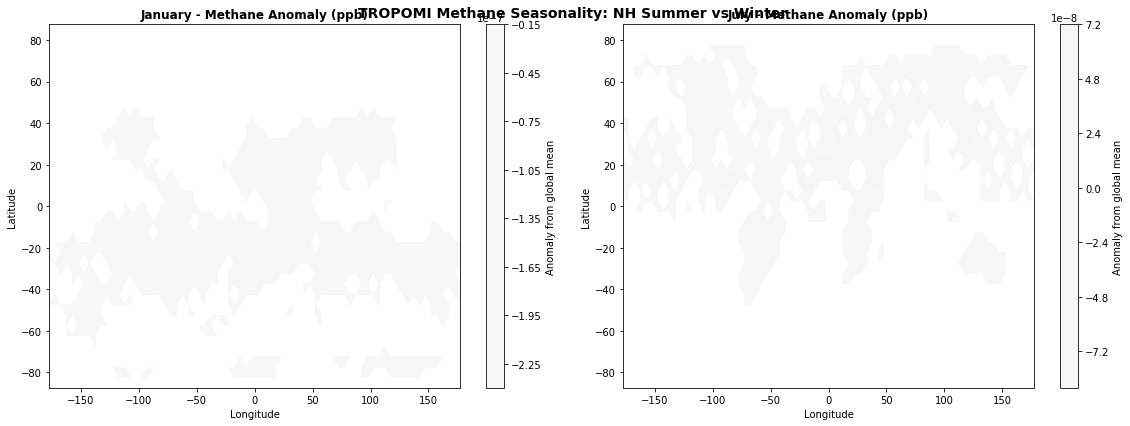


✓ Seasonal comparison saved!


In [15]:

import matplotlib.pyplot as plt


# Calculate ANOMALIES (difference from global mean)
xch4_all = ds['xch4'].values  # (time, lat, lon)
global_mean = np.nanmean(xch4_all)  # Global mean
print(f"\nGlobal mean CH4: {global_mean:.2f} ppb")

# Get January (first timestep) and July (middle)
jan_xch4 = ds['xch4'].isel(time=0).values
july_xch4 = ds['xch4'].isel(time=len(ds.time)//2).values

# Calculate anomalies (deviation from global mean)
jan_anom = jan_xch4 - global_mean
july_anom = july_xch4 - global_mean

print(f"\nJanuary anomaly range: {np.nanmin(jan_anom):.3f} to {np.nanmax(jan_anom):.3f} ppb")
print(f"July anomaly range: {np.nanmin(july_anom):.3f} to {np.nanmax(july_anom):.3f} ppb")

# Create seasonal comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im1 = axes[0].contourf(ds.lon, ds.lat, jan_anom, levels=20, cmap='RdBu_r', vmin=-0.05, vmax=0.05)
axes[0].set_title('January - Methane Anomaly (ppb)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(im1, ax=axes[0], label='Anomaly from global mean')

im2 = axes[1].contourf(ds.lon, ds.lat, july_anom, levels=20, cmap='RdBu_r', vmin=-0.05, vmax=0.05)
axes[1].set_title('July - Methane Anomaly (ppb)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(im2, ax=axes[1], label='Anomaly from global mean')

plt.suptitle('TROPOMI Methane Seasonality: NH Summer vs Winter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06-tropomi-seasonal-anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Seasonal comparison saved!")

In [10]:
print("Time range in this file:")
print(f"First: {ds.time.values[0]}")
print(f"Last: {ds.time.values[-1]}")
print(f"Total timesteps: {len(ds.time)}")

Time range in this file:
First: 2003-01-16T12:00:00.000000000
Last: 2023-12-16T12:00:00.000000000
Total timesteps: 252
